# V6 — 华尔街 PE 估值体系：从"名义总成本"到 NPV / LCOE / CVaR

V3 的 U 型曲线只比较名义总成本（`argmin(总成本)`），在金融学上不及格——它忽略了**资金的时间价值**。本 notebook 重写资本配置决策：

1. 对每个候选电池容量，用**两阶段随机引擎**求出气候不确定性下的**期望日运营成本**与**成本分布**。
2. 将未来 10 年每年省下的碳税+燃料按 8% 贴现，减去今日 CAPEX，得到真实 **NPV**。
3. 最优容量判据从 `argmin(成本)` 升级为 **`argmax(NPV)`**。
4. 叠加 **CVaR**（条件风险价值）曲线，量化储能对极端天气尾部风险的对冲价值。

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

from ecogrid import (
    FinanceConfig,
    GridConfig,
    ScenarioConfig,
    StochasticDispatchEngine,
    cvar,
    generate_scenarios,
    npv,
)

plt.rcParams["figure.dpi"] = 110
plt.style.use("dark_background")

# ---- 预测基线：鸭子曲线 + 蒙特卡洛情景集 ----
H = 24
hours = np.arange(H)
demand = 80 + 60 * np.exp(-((hours - 19) ** 2) / 7) - 32 * np.exp(-((hours - 12) ** 2) / 9)
solar_fc = np.clip(62 * np.exp(-((hours - 12.5) ** 2) / 10), 0, 55)
wind_fc = np.clip(30 + 15 * np.cos(hours / 24 * 2 * np.pi + 3.0), 0, 45)

scen = generate_scenarios(wind_fc, solar_fc, ScenarioConfig(n_scenarios=50, seed=7))
fin = FinanceConfig(unit_capex=300_000.0, discount_rate=0.08, lifespan_years=10, cvar_alpha=0.95)
print(
    f"情景数={scen.n_scenarios} | 贴现率={fin.discount_rate:.0%} | "
    f"寿命={fin.lifespan_years}年 | 单位CAPEX=€{fin.unit_capex:,.0f}/MWh"
)


情景数=50 | 贴现率=8% | 寿命=10年 | 单位CAPEX=€300,000/MWh


In [2]:
# ---- 容量网格扫描：每个容量跑一次随机优化，记录期望成本与成本分布 ----
capacities = np.arange(0, 281, 20, dtype=float)
exp_opex, cvar_daily = [], []

for cap in capacities:
    cfg = GridConfig(carbon_tax_rate=120.0, bess_capacity=float(cap), coal_pmin=25.0,
                     coal_pmax=200.0, startup_cost=2000.0, min_up_time=3, min_down_time=2)
    r = StochasticDispatchEngine(cfg).solve(demand, scen)
    exp_opex.append(r.expected_cost)
    cvar_daily.append(cvar(r.scenario_costs, fin.cvar_alpha))

exp_opex = np.array(exp_opex)
cvar_daily = np.array(cvar_daily)

# ---- DCF / NPV：年省 = (基线日成本 - 当前日成本) * 365，再贴现 10 年减 CAPEX ----
daily_savings = exp_opex[0] - exp_opex
annual_savings = daily_savings * 365.0
capex = capacities * fin.unit_capex
npv_curve = np.array([
    npv(annual_savings[i], capex[i], fin.discount_rate, fin.lifespan_years)
    for i in range(len(capacities))
])

opt_idx = int(np.argmax(npv_curve))
opt_cap = capacities[opt_idx]
print(f"最优投资容量 (argmax NPV) = {opt_cap:.0f} MWh | 最大 NPV = €{npv_curve[opt_idx]:,.0f}")
print(
    f"对比：若按 argmin(日成本) 则会一路买到 "
    f"{capacities[int(np.argmin(exp_opex))]:.0f} MWh（忽视资金成本，过度投资）"
)


最优投资容量 (argmax NPV) = 140 MWh | 最大 NPV = €16,811,298
对比：若按 argmin(日成本) 则会一路买到 280 MWh（忽视资金成本，过度投资）


C:\Users\Averyhong\AppData\Local\Temp\ipykernel_19368\602454664.py:25: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_19368\602454664.py:25: UserWarning: Glyph 27744 (\N{CJK UNIFIED IDEOGRAPH-6C60}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_19368\602454664.py:25: UserWarning: Glyph 23481 (\N{CJK UNIFIED IDEOGRAPH-5BB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_19368\602454664.py:25: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_19368\602454664.py:25: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEOGRAPH-51C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_19368\602454664.py:25: UserWarni

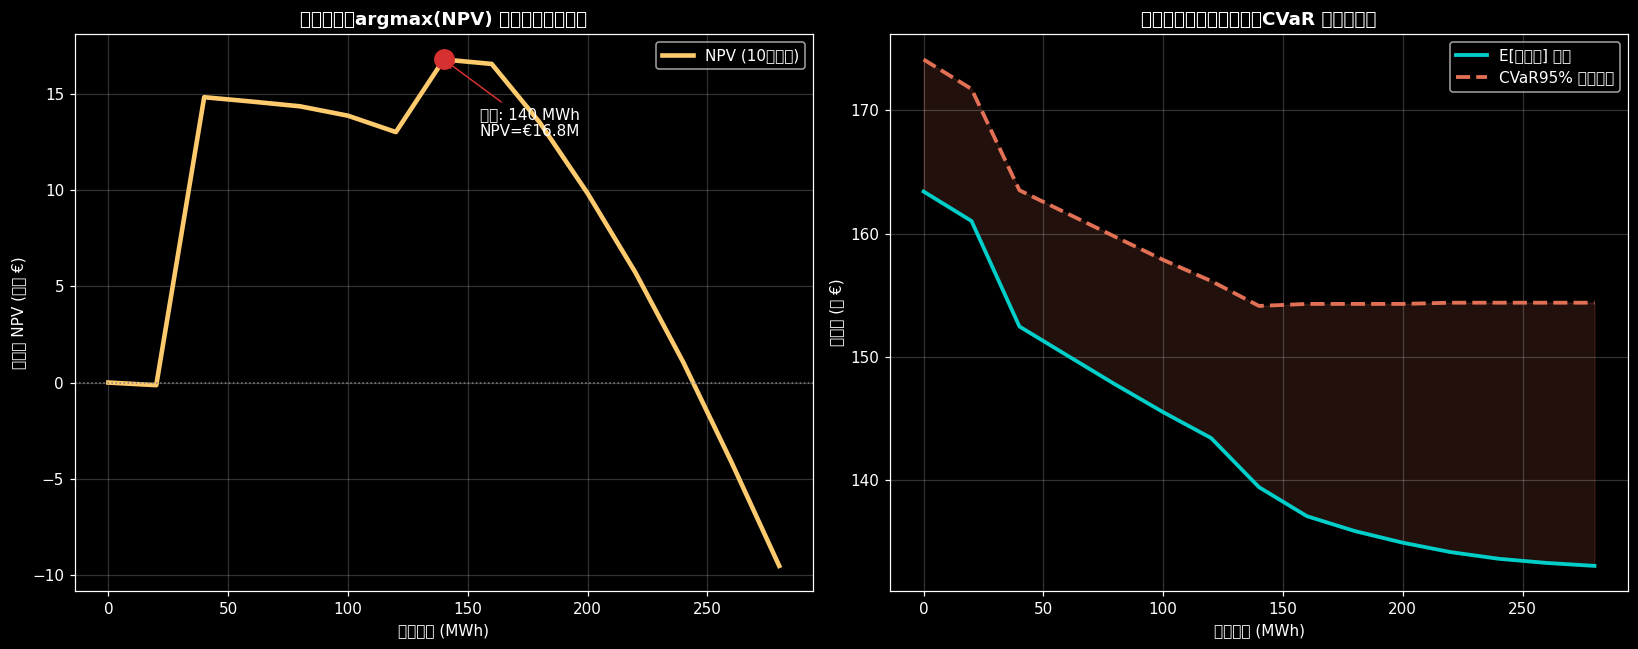

In [3]:
# ---- 可视化：NPV 资本曲线 + 尾部风险 CVaR 曲线 ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(capacities, npv_curve / 1e6, color="#fdcb6e", linewidth=3, label="NPV (10年贴现)")
ax1.axhline(0, color="grey", linestyle=":", linewidth=1)
ax1.scatter(opt_cap, npv_curve[opt_idx] / 1e6, color="#d63031", s=160, zorder=5)
ax1.annotate(f"最优: {opt_cap:.0f} MWh\nNPV=€{npv_curve[opt_idx]/1e6:.1f}M",
             xy=(opt_cap, npv_curve[opt_idx] / 1e6),
             xytext=(opt_cap + 15, npv_curve[opt_idx] / 1e6 - 4),
             color="white", arrowprops=dict(arrowstyle="->", color="#d63031"))
ax1.set_xlabel("电池容量 (MWh)")
ax1.set_ylabel("净现值 NPV (百万 €)")
ax1.set_title("资本定价：argmax(NPV) 决定最优投资规模", fontweight="bold")
ax1.legend()
ax1.grid(alpha=0.2)

ax2.plot(capacities, exp_opex / 1e3, color="#00cec9", linewidth=2.5, label="E[日成本] 期望")
ax2.plot(capacities, cvar_daily / 1e3, color="#e17055", linewidth=2.5, linestyle="--",
         label=f"CVaR{fin.cvar_alpha:.0%} 尾部风险")
ax2.fill_between(capacities, exp_opex / 1e3, cvar_daily / 1e3, color="#e17055", alpha=0.15)
ax2.set_xlabel("电池容量 (MWh)")
ax2.set_ylabel("日成本 (千 €)")
ax2.set_title("储能对冲气候尾部风险：CVaR 随容量收敛", fontweight="bold")
ax2.legend()
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()
